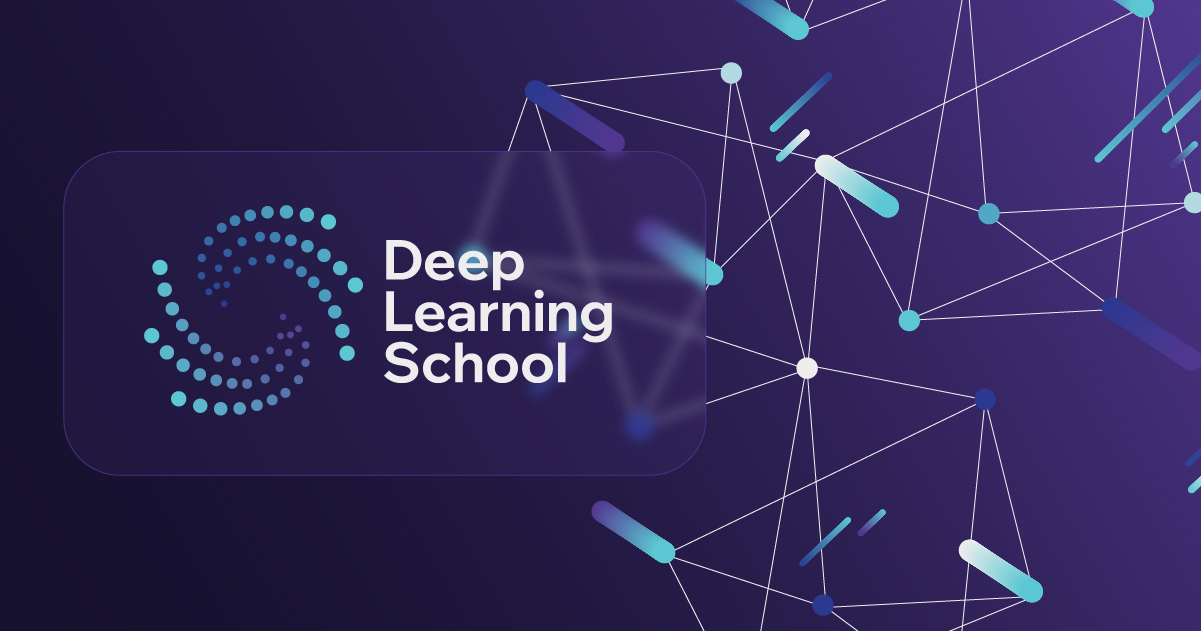


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация изображений</b></h3>


# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



В нашем тесте будет 991 картинка, для которых вам будет необходимо предсказать класс.

## Шаг 1. Установка зависимостей

####Установим необходимые библиотеки и проверим доступность CUDA

In [1]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [ ]:
!nvidia-smi

Tue Mar 17 10:06:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import pickle
import numpy as np
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from torchvision.transforms import v2

import torchsummary

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)


#### Проверим версии Python и библиотек
Посмотрим, какие версии установлены:

In [ ]:
!python --version
from importlib.metadata import version
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ version(b))

Python 3.12.12
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
tqdm version: 4.67.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
Pillow version: 11.3.0


Сверим с версиями питона и библиотек, на которых работал эталонный ноутбук:

- Python 3.12.12
- torch version: 2.8.0+cu126
- torchvision version: 0.23.0+cu126
- tqdm version: 4.67.1
- matplotlib version: 3.10.0
- seaborn version: 0.13.2
- Pillow version: 11.3.0


 #### Определим константы, которые будем использовать в по ходу ноутбука

In [3]:
from pathlib import Path
import os

if Path("/content").exists():
    BASE_DIR = Path("/content")
    print("🔵 Google Colab detected")
else:
    BASE_DIR = Path("content")
    print("🟢 Local PC detected")

🟢 Local PC detected


In [4]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']

# работаем на видеокарте
DEVICE = torch.device("cuda")

#определим директории с тренировочными и тестовыми файлами
# TRAIN_DIR = Path('/content/train') #Path('./data/train/')
# TEST_DIR = Path('/content/testset') #Path('./data/testset')

TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "testset"

# параметры нормировки изображений по трем каналам перед подачей в модель
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = [224, 224]

## Шаг 2. Загрузка и обработка данных

#### Скачаем изображения по ссылке

In [ ]:
!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

Downloading...
From (original): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1
From (redirected): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1&confirm=t&uuid=987ff69d-b15b-45d8-af53-fb997b8d39d3
To: /content/journey-springfield.zip
100% 546M/546M [00:09<00:00, 60.4MB/s]


In [ ]:
!unzip -q /content/journey-springfield.zip

Посмотрите на структуру файлов в папках train и testset.

В train лежат данные, которые мы будем использовать для обучения модели. Изображения персонажей разложены по папкам, которые названы по именам персонажей. Названия папок мы в дальнейшем будет использовать в качестве текстовых меток классов.

В testset находятся изображения, для которых вам надо будет сделать прогноз наиболее вероятного класса.


Для обращения к файлам сформируем списки имен файлов обучающей+валидационнной и тестовой выборок. Это полные имена, включающие путь к файлам.


In [23]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

Кодировать имена персонажей в числовые метки класса и обратно будем при помощи `LabelEncoder`.

Для train выборки сформируем список текстовых меток всех изображений - имя родительской директории, которая одновременно является и именем персонажа. Зададим числовые метки классов нашего энкодера при помощи метода `fit`.

Далее будем применять метод `transform` для преобразования текстовых меток в числовые, и метод `inverse_transform` для преобразования числовых меток в текстовые.


In [24]:
label_encoder = LabelEncoder()

train_val_labels = [path.parent.name for path in train_val_files]

label_encoder.fit(train_val_labels)

LabelEncoder()

Разделим train выборку на обучающую и валидационнную части. Для того, чтобы персонажи были пропорционально представлены в обучающей и валидационнной подвыборках, применим стратификацию по меткам класса.

In [25]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

####Создадим Datasets и Dataloaders

Полезная статья, которой мы вдохновились при создании класса `SimpsonsDataset`:
https://jhui.github.io/2018/02/09/PyTorch-Data-loading-preprocess_torchvision/


У нас есть набор файлов-картинок, которые требуется преобразовать в тензоры, и добавить к ним числовые метки классов. Реализуем это с помощью созданного нами класса `SimpsonsDataset`, который из списка файлов создаст необходимый нам Dataset.  

Будем действовать согласно инструкции из документации (https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files):
- наш класс будет наследовать от класса Dataset
- мы переопределим методы `__init__`, `__len__` и `__getitem__`, а также для удобства добавим несколько методов для загрузки и преобразования изображений.

Важно разобраться, что делает метод self.transform_images_to_tensors().

`Compose` объединяет последовательность следующих преобразований:
- `PILToTensor` конвертирует  `PIL Image` в тензор с параметрами в диапазоне $[0, 255]$ (как все пиксели в исходном изображении)
- `ToDtype` преобразует тензор в `FloatTensor` размера ($C \times H \times W$) со значениями пикселей в диапазоне $[0,1]$
- затем `Normalize` производится масштабирование:
$\text{input} = \frac{\text{input} - \text{mean}}{\text{std}} $, <br>      где константы mean и std - средние и дисперсии по каналам в датасете ImageNet
- наконец, `Resize` преобразует картинки к размеру $224 \times 224$ (в описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следует привести их к одному размеру).

Сейчас аугментация не изображений не производится, поэтому для обучающих и валидационных/тестовых изображений производится одинаковая трансформация. В дальнейшем, если вы захотите добавить аугментацию, вы можете сделать это, например, модифицировав метод `transform_images_to_tensors`. Подробнее про трансформацию изображений вы можете почитать в документации: https://docs.pytorch.org/vision/main/transforms.html


In [26]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_ # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.
        # Если вы решите перевзвесить размеры категорий внутри класса -
        # не забудьте изменить вывод self.__len__()

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            #v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
            v2.Resize(RESCALE_SIZE),
          ])
      else:
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)


In [27]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

In [28]:
batch_size = 64

In [29]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

#### Посмотрим на изображения персонажей

Напишем функцию для визуализации картинок. Это аналог Imshow, которая будет принимать на вход тензоры

In [30]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Проверим, как работает наша функция. Возьмем один батч из лоадера и подадим на вход функции первый тензор из этого батча. Заодно посмотрим, как работает кодировщик меток класса.

Числовая метка класса: 7
Текстовая метка класса: ['chief_wiggum']


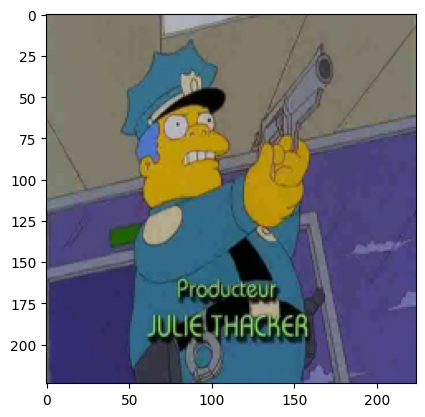

In [16]:
image_tensor, label = next(iter(train_loader))
print(f"Числовая метка класса: {label[0]}")
print(f"Текстовая метка класса: {label_encoder.inverse_transform([label[0],])}")
imshow(image_tensor[0])


In [ ]:
# uncomment if you have problem with pillow
# def register_extension(id, extension): Image.EXTENSION[extension.lower()] = id.upper()
# Image.register_extension = register_extension
# def register_extensions(id, extensions):
#     for extension in extensions: register_extension(id, extension)
# Image.register_extensions = register_extensions

Давайте посмотрим на наших героев внутри датасета.

In [ ]:
def show_images(n_rows, n_cols, dataset):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in ax.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # получаем изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()
    fig_x.set_axis_off()
  return None

**!** Обратите внимание, что возможно, датасет требует дополнительной фильтрации, так как лейблы не всегда точно соответствуют картинкам. Очистка датасета - это один из способов повысить качество модели. Этим можно будет заняться во второй части домашнего задания.

Запустим написанную функцию.

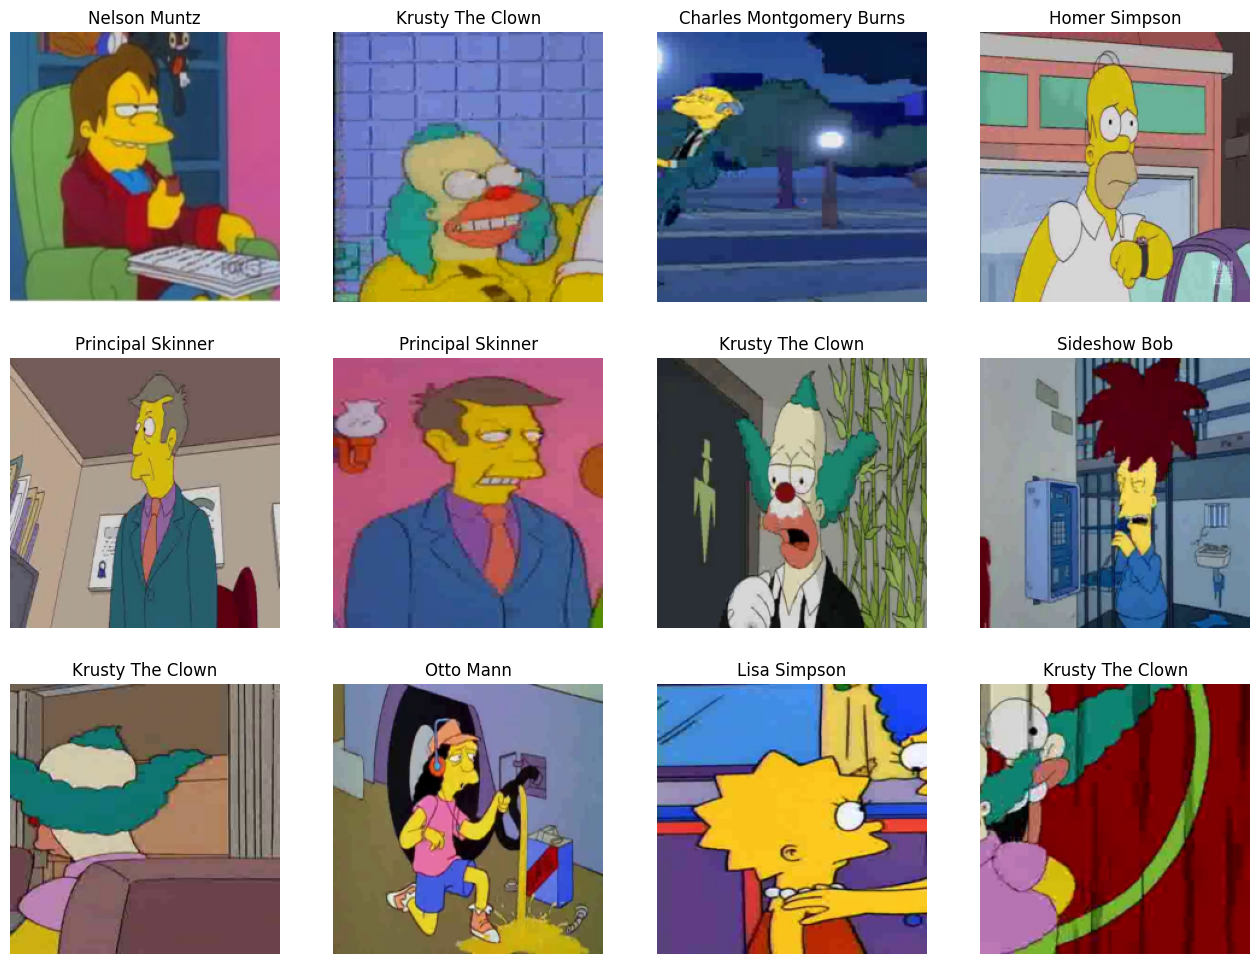

In [ ]:
show_images(n_rows = 3, n_cols = 4, dataset = val_dataset)

## Шаг 3. Построение нейросети

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle.

О том, как работают свёртки подробней можно прочитать в документации Pytorch на функцию `Conv2d`:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Калькулятор свёрток:

https://madebyollin.github.io/convnet-calculator/

#### Модель

In [31]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

*Описание слоев*:

1. размерность входа: $3\times 224 \times 224$
2. размерность после 1-го слоя (Conv2d + ReLU + MaxPool2d):  $8 \times 111 \times 111$
3. после 2-го слоя: $16 \times 54 \times 54$
4. после 3-го слоя: $32 \times 26 \times 26$
5. после 4-го слоя: $64 \times 12 \times 12$
6. после 5-го слоя: $96 \times 5 \times 5$
7. после полносвязного слоя (выход модели): количество классов

In [ ]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
         MaxPool2d-3          [-1, 8, 111, 111]               0
            Conv2d-4         [-1, 16, 109, 109]           1,168
              ReLU-5         [-1, 16, 109, 109]               0
         MaxPool2d-6           [-1, 16, 54, 54]               0
            Conv2d-7           [-1, 32, 52, 52]           4,640
              ReLU-8           [-1, 32, 52, 52]               0
         MaxPool2d-9           [-1, 32, 26, 26]               0
           Conv2d-10           [-1, 64, 24, 24]          18,496
             ReLU-11           [-1, 64, 24, 24]               0
        MaxPool2d-12           [-1, 64, 12, 12]               0
           Conv2d-13           [-1, 96, 10, 10]          55,392
             ReLU-14           [-1, 96,

##Шаг 4. Функции для работы с моделью

#### Задание - напишите функции для работы с моделью

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе -- `f1-score`.

Ниже приводится код для вычисления целевой метрики.

In [5]:
from sklearn.metrics import f1_score
# пример расчета: f1 = f1_score(actual_labels, y_predicted, average='micro')

В этом задании может быть полезным сделать, чтобы функция валидации и, возможно, функция обучения на одной эпохе возвращали векторы/тензоры:
- предсказанного наиболее вероятного класса
- и фактических меток класса для каждого объекта.

Сама метрика f1, при этом, будет вычисляться не внутри функции, а вне ее, сопоставляя прогнозные и фактические значения, полученные из вывода функции.

Это поможет проанализировать, при предсказании каких классов модель ошибается чаще. Также такой подход может использоваться для обнаружения изображений, которые модель классифицирует неверно.

Для ускорения вычислений рекомендуется при работе с моделью проводить тензорные вычисления на GPU. Обращаем внимание, для этого необходимо, чтобы и данные, и модель находились на одном устройстве.

Ниже представлен код из предыдущего домашнего задания, который демонстрировал логику циклов обучения и валидации. Ниже в этот код добавлены строки комментарии, показывающие как переносить модель и данные на устройство.


```python
model.to(DEVICE)  # <- переносим модель на устройство DEVICE

for epoch in range(max_epochs):  
    # режим train
    model.train()  
    for x_batch, y_batch in train_dataloader:
        x_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        y_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        
        optimizer.zero_grad()
        outp = model(x_batch)
        loss = criterion(outp, y_batch)
        loss.backward()  
        optimizer.step()
        
        count_metrics(outp, y_batch)  # <-здесь, скорее всего, потребуется перенести данные на cpu, например с помощью метода cpu: metrics.cpu()
     
     # режим test/eval
     model.eval()  
     for x_batch, y_batch in val_dataloader:
        x_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        y_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        
        with torch.no_grad():
            outp = model(x_batch)
            count_metrics(outp, y_batch) # <-здесь, скорее всего, потребуется перенести данные на cpu       
```

Напишите функции:
- для обучения модели на одной эпохе
- для валидации модели на одной эпохе
- для реализации полного цикла обучения

За основу можно взять функции, которые вы написали в предыдущем домашнем задании.

In [6]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func):

  y_predicted = []
  actual_labels = []

  model.train()
  for X_batch, y_batch in tqdm(train_dataloader):
    X_batch = X_batch.to(DEVICE)
    y_batch = y_batch.to(DEVICE)

    optimizer.zero_grad()

    outp = model(X_batch)
    loss = loss_func(outp, y_batch)

    loss.backward()
    optimizer.step()

    preds = outp.argmax(-1)

    y_predicted.extend(preds.cpu().numpy())
    actual_labels.extend(y_batch.cpu().numpy())

  return np.array(actual_labels), np.array(y_predicted)

  # YOUR CODE

In [7]:
def eval_one_epoch(model, val_dataloader):

  y_predicted = []
  actual_labels = []

  model.eval()

  for X_batch, y_batch in tqdm(val_dataloader):
    X_batch = X_batch.to(DEVICE)
    y_batch = y_batch.to(DEVICE)

    with torch.no_grad():
      outp = model(X_batch)
      preds = outp.argmax(-1)

      y_predicted.extend(preds.cpu().numpy())
      actual_labels.extend(y_batch.cpu().numpy())

  return np.array(actual_labels), np.array(y_predicted)

  # YOUR CODE

In [8]:
def train_func(model, num_epochs, dataloaders, optimizer, loss_func): # для colab

  best_f1 = -1
  best_epoch = -1

  f1_scores = {"train": [], "valid": []}

  for epoch in range(num_epochs):
    print(f"\nEpoch: {epoch+1}")

    actual_labels_train, y_predicted_train = fit_one_epoch(model = model, train_dataloader = dataloaders['train'], optimizer = optimizer, loss_func = loss_func)
    f1_train = f1_score(actual_labels_train, y_predicted_train, average='micro')

    print(f"f1_score_train: {f1_train:.4f}\n")

    actual_labels_val, y_predicted_val = eval_one_epoch(model = model, val_dataloader = dataloaders['val'])
    f1_val = f1_score(actual_labels_val, y_predicted_val, average='micro')
    print(f"f1_score_val: {f1_val:.4f}\n")

    f1_scores['train'].append(f1_train)
    f1_scores['valid'].append(f1_val)

    best_f1 = max(best_f1, f1_val)
    best_epoch = epoch if best_f1 == f1_val else best_epoch

  print()
  print("results:")
  print(f"best f1 for val set: {best_f1:.4f}")
  print(f"best epoch for val set: {best_epoch + 1}")

  return f1_scores

# YOUR CODE

## Шаг 5. Применение модели к данным

#### Применение модели к данным

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 1e-3)

Запустите обучение сети

In [ ]:
f1_scores = train_func(model = model_simple_cnn, num_epochs = 10, dataloaders = loaders, optimizer = optimizer, loss_func = criterion)

# YOUR CODE


Epoch: 1


100%|██████████| 246/246 [02:10<00:00,  1.88it/s]


f1_score_train: 0.2438



100%|██████████| 82/82 [00:39<00:00,  2.05it/s]


f1_score_val: 0.4178


Epoch: 2


...

f1_score_val: 0.7822


Epoch: 10


100%|██████████| 246/246 [02:17<00:00,  1.78it/s]


f1_score_train: 0.9573



100%|██████████| 82/82 [00:40<00:00,  2.04it/s]

f1_score_val: 0.7776


results:
best f1 for val set: 0.7822
best epoch for val set: 9


(опционально) Постройте график динамики метрик модели по ходу обучения

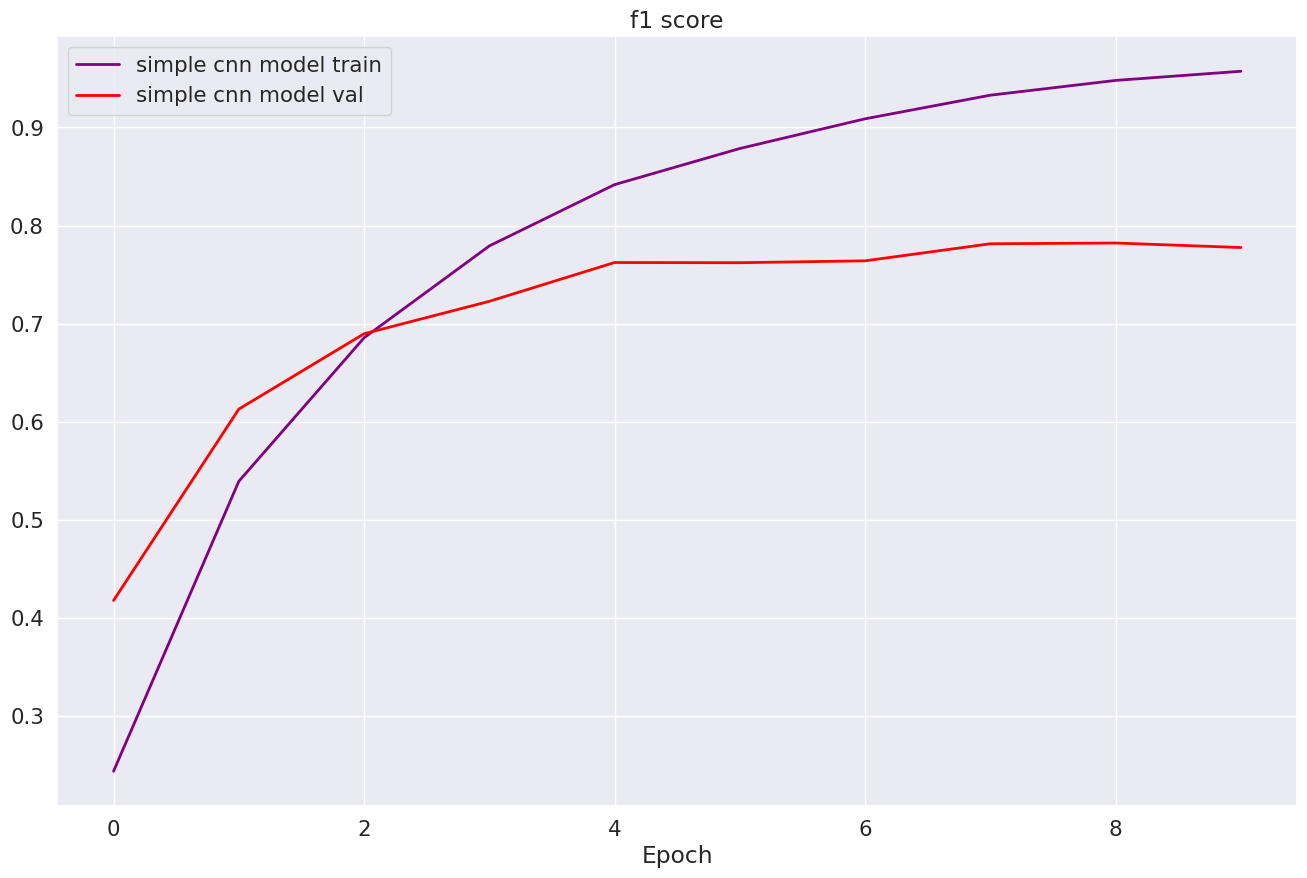

In [ ]:
import seaborn as sns

sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("f1 score")
plt.plot(range(10), f1_scores["train"], label="simple cnn model train", linewidth=2, color = 'purple')
plt.plot(range(10), f1_scores["valid"], label="simple cnn model val", linewidth=2, color = 'red')
plt.legend()
plt.xlabel("Epoch")
plt.show()

# YOUR CODE

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах.

In [ ]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

@torch.no_grad()
def show_images2(n_rows, n_cols, dataset, model):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in axs.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # выводим изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()

    # ниже представлен код для добавления на изображение подписи с вероятностью класса
    actual_text = "Actual : {}".format(img_label)


    font0 = FontProperties()
    font = font0.copy()

    # наша модель возвращает логиты, поэтому для получения вероятностей классов не забываем применить softmax:
    prob_pred = nn.functional.softmax(model(im_val.unsqueeze(0).to(DEVICE)), dim = -1).cpu().numpy()

    predicted_proba = np.max(prob_pred)*100 # берем максимальную вероятность класса
    y_pred = np.argmax(prob_pred) # берем числовую метку класса, для которого вероятность максимальна

    predicted_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([y_pred])[0].split('_')))
    predicted_text = "{}:\n {:.1f}%".format(predicted_label, predicted_proba)

    fig_x.add_patch(patches.Rectangle((0, 190), 7*len(predicted_label), 25,color='white'))
    fig_x.text(2, 195, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')
    fig_x.set_axis_off()

  return None

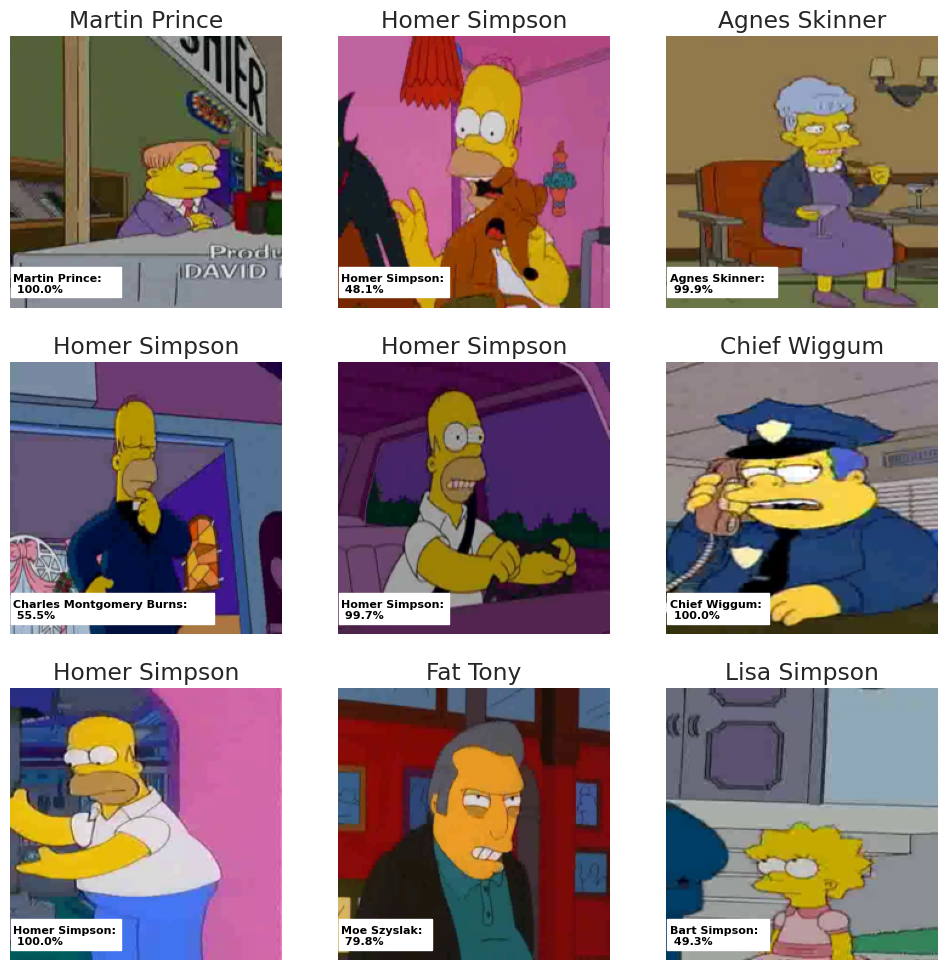

In [ ]:
show_images2(n_rows = 3, n_cols = 3, dataset = val_dataset, model = model_simple_cnn)

## Шаг 6. Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

Создадим loader для тестовых данных

In [ ]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

Воспользуемся функцией predict, которая возвращает предсказанные числовые метки для всех объектов в лоадере.

In [9]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")
    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

Получем предсказание меток классов для тестовых данных:

In [ ]:
predicted_numeric_labels = predict(model_simple_cnn, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

и преобразуем их в текстовые метки:

In [ ]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

Загрузим пример файла для загрузки на Kaggle (проверьте путь, по которому у вас лежит файл sample_submission.csv и при необходимости скорректируйте путь в коде ниже):

In [ ]:
import pandas as pd
sample_submission = pd.read_csv("/content/sample_submission.csv")
sample_submission.head(10)

,Id,Expected
0,img0.jpg,bart_simpson
1,img1.jpg,bart_simpson
2,img2.jpg,bart_simpson
3,img3.jpg,bart_simpson
4,img4.jpg,bart_simpson
5,img5.jpg,bart_simpson
6,img6.jpg,bart_simpson
7,img7.jpg,bart_simpson
8,img8.jpg,bart_simpson
9,img9.jpg,bart_simpson


In [ ]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [ ]:
# TODO : сделайте сабмит (это важно, если Вы не справляетесь, но дошли до этой ячейки, то сообщите в чат и Вам помогут)

In [ ]:
my_submission.to_csv('simple_cnn_baseline.csv', index=False)

## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся score нас явно не устраивает. Надо с этим что-то сделать.

Вам предлагается творческая и исследовательская свобода в том, как вы будете улучшать score модели. Вот некоторые направления, которые вы, возможно, захотите попробовать:
1. Работа с датасетом:
* Попробуйте увеличить разнообразие обучающей выборки при помощи аугментации ([ссылка 1](https://habr.com/ru/companies/smartengines/articles/264677/), [ссылка 2](https://www.geeksforgeeks.org/python-data-augmentation/));
* Используя результаты функции eval_one_epoch, вы можете посмотреть, как метрика f1-score внутри класса связана с размером самого класса в обучающей выборке. Скорее всего, вы заметите прямую зависимость. Решением может быть увеличение размеров слабо представленных классов. Сделать это можно, вручную добавив этот функционал в SimpsonsDataset или воспользовавшись инструментом WeightedRandomSampler.

* Также вы можете изучить, какие изображения модель классифицирует неверно. Можно просто посмотреть неверно классифицированные изображения в валидационном датасете. Можно попробовать более фундаментальный подход - создать dataloader из всех изображений обучающей и валидационной выборки в SimpsonsDataset c режимом 'val', прогнать данные через обученную модель simple_cnn. Более того, можно обучить несколько моделей с разной архитектурой, и прогнать объединенный датасет через все эти модели - и выделить те изображения, в классификации которых ошиблись несколько моделей.

* Это поможет понять, как качество и чистота исходных данных влияет на результаты обучения модели. Если вы обнаружите ошибки в simpsons_dataset и решите их исправить или удалить некоторые изображения из обучающей выборки - сделайте это в ноутбуке, чтобы при проверке можно было повторить результаты работы вашего кода.  

2. Работа с архитектурой сети:
* учим дольше и изменяем (подбираем) гиперпараметры: learning rate, batch size, нормализация картинки и вот это всё;
* добавление/удаление свёрточных и полносвязных слоёв;
* А еще есть где пулинги и батч-норм!

3. Применение техник, описанных в предыдущих пунктах, позволяет добиться довольно высоких результатов. Но вы можете попробовать файнтютинг и трансферлёнинг:
* ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

4. Улучшение оптимизации:
* ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

5. Наконец, возможно, стоит подумать об ансамблях


Надеюсь, что у Вас получится!

##**Этап 2. Доработка нейросети.**

На текущий момент мой результат на Kaggle: 0.93942.

Посмотрим на статистику предсказаний по классам в валидационной выборке.

Посмотрим на classification_report:

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

actual_labels_val, y_predicted_val = eval_one_epoch(model_simple_cnn, loaders['val'])

# Преобразуем числовые метки обратно в исходные названия
actual_labels_names = label_encoder.inverse_transform(actual_labels_val)
predicted_labels_names = label_encoder.inverse_transform(y_predicted_val)

# Получаем уникальные названия классов для отчета
class_names = label_encoder.classes_

100%|██████████| 82/82 [00:40<00:00,  2.04it/s]


In [ ]:
report_dict = classification_report(
    actual_labels_names,
    predicted_labels_names,
    labels=class_names,
    output_dict=True,
    digits=4
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
df_report = pd.DataFrame(report_dict).T
df_report = df_report[df_report.index.isin(class_names)]  # оставляем только классы

# СОРТИРУЕМ ПО F1-SCORE (по возрастанию)
df_sorted = df_report.sort_values('f1-score', ascending=True)

In [ ]:
df_sorted

,precision,recall,f1-score,support
disco_stu,0.000000,0.000000,0.000000,2.0
lionel_hutz,0.000000,0.000000,0.000000,1.0
miss_hoover,0.000000,0.000000,0.000000,4.0
gil,1.000000,0.142857,0.250000,7.0
sideshow_mel,0.333333,0.200000,0.250000,10.0
patty_bouvier,0.666667,0.222222,0.333333,18.0
barney_gumble,0.529412,0.346154,0.418605,26.0
agnes_skinner,0.750000,0.300000,0.428571,10.0
fat_tony,1.000000,0.285714,0.444444,7.0
maggie_simpson,0.647059,0.343750,0.448980,32.0


Посмотрим на confusion_matrix:

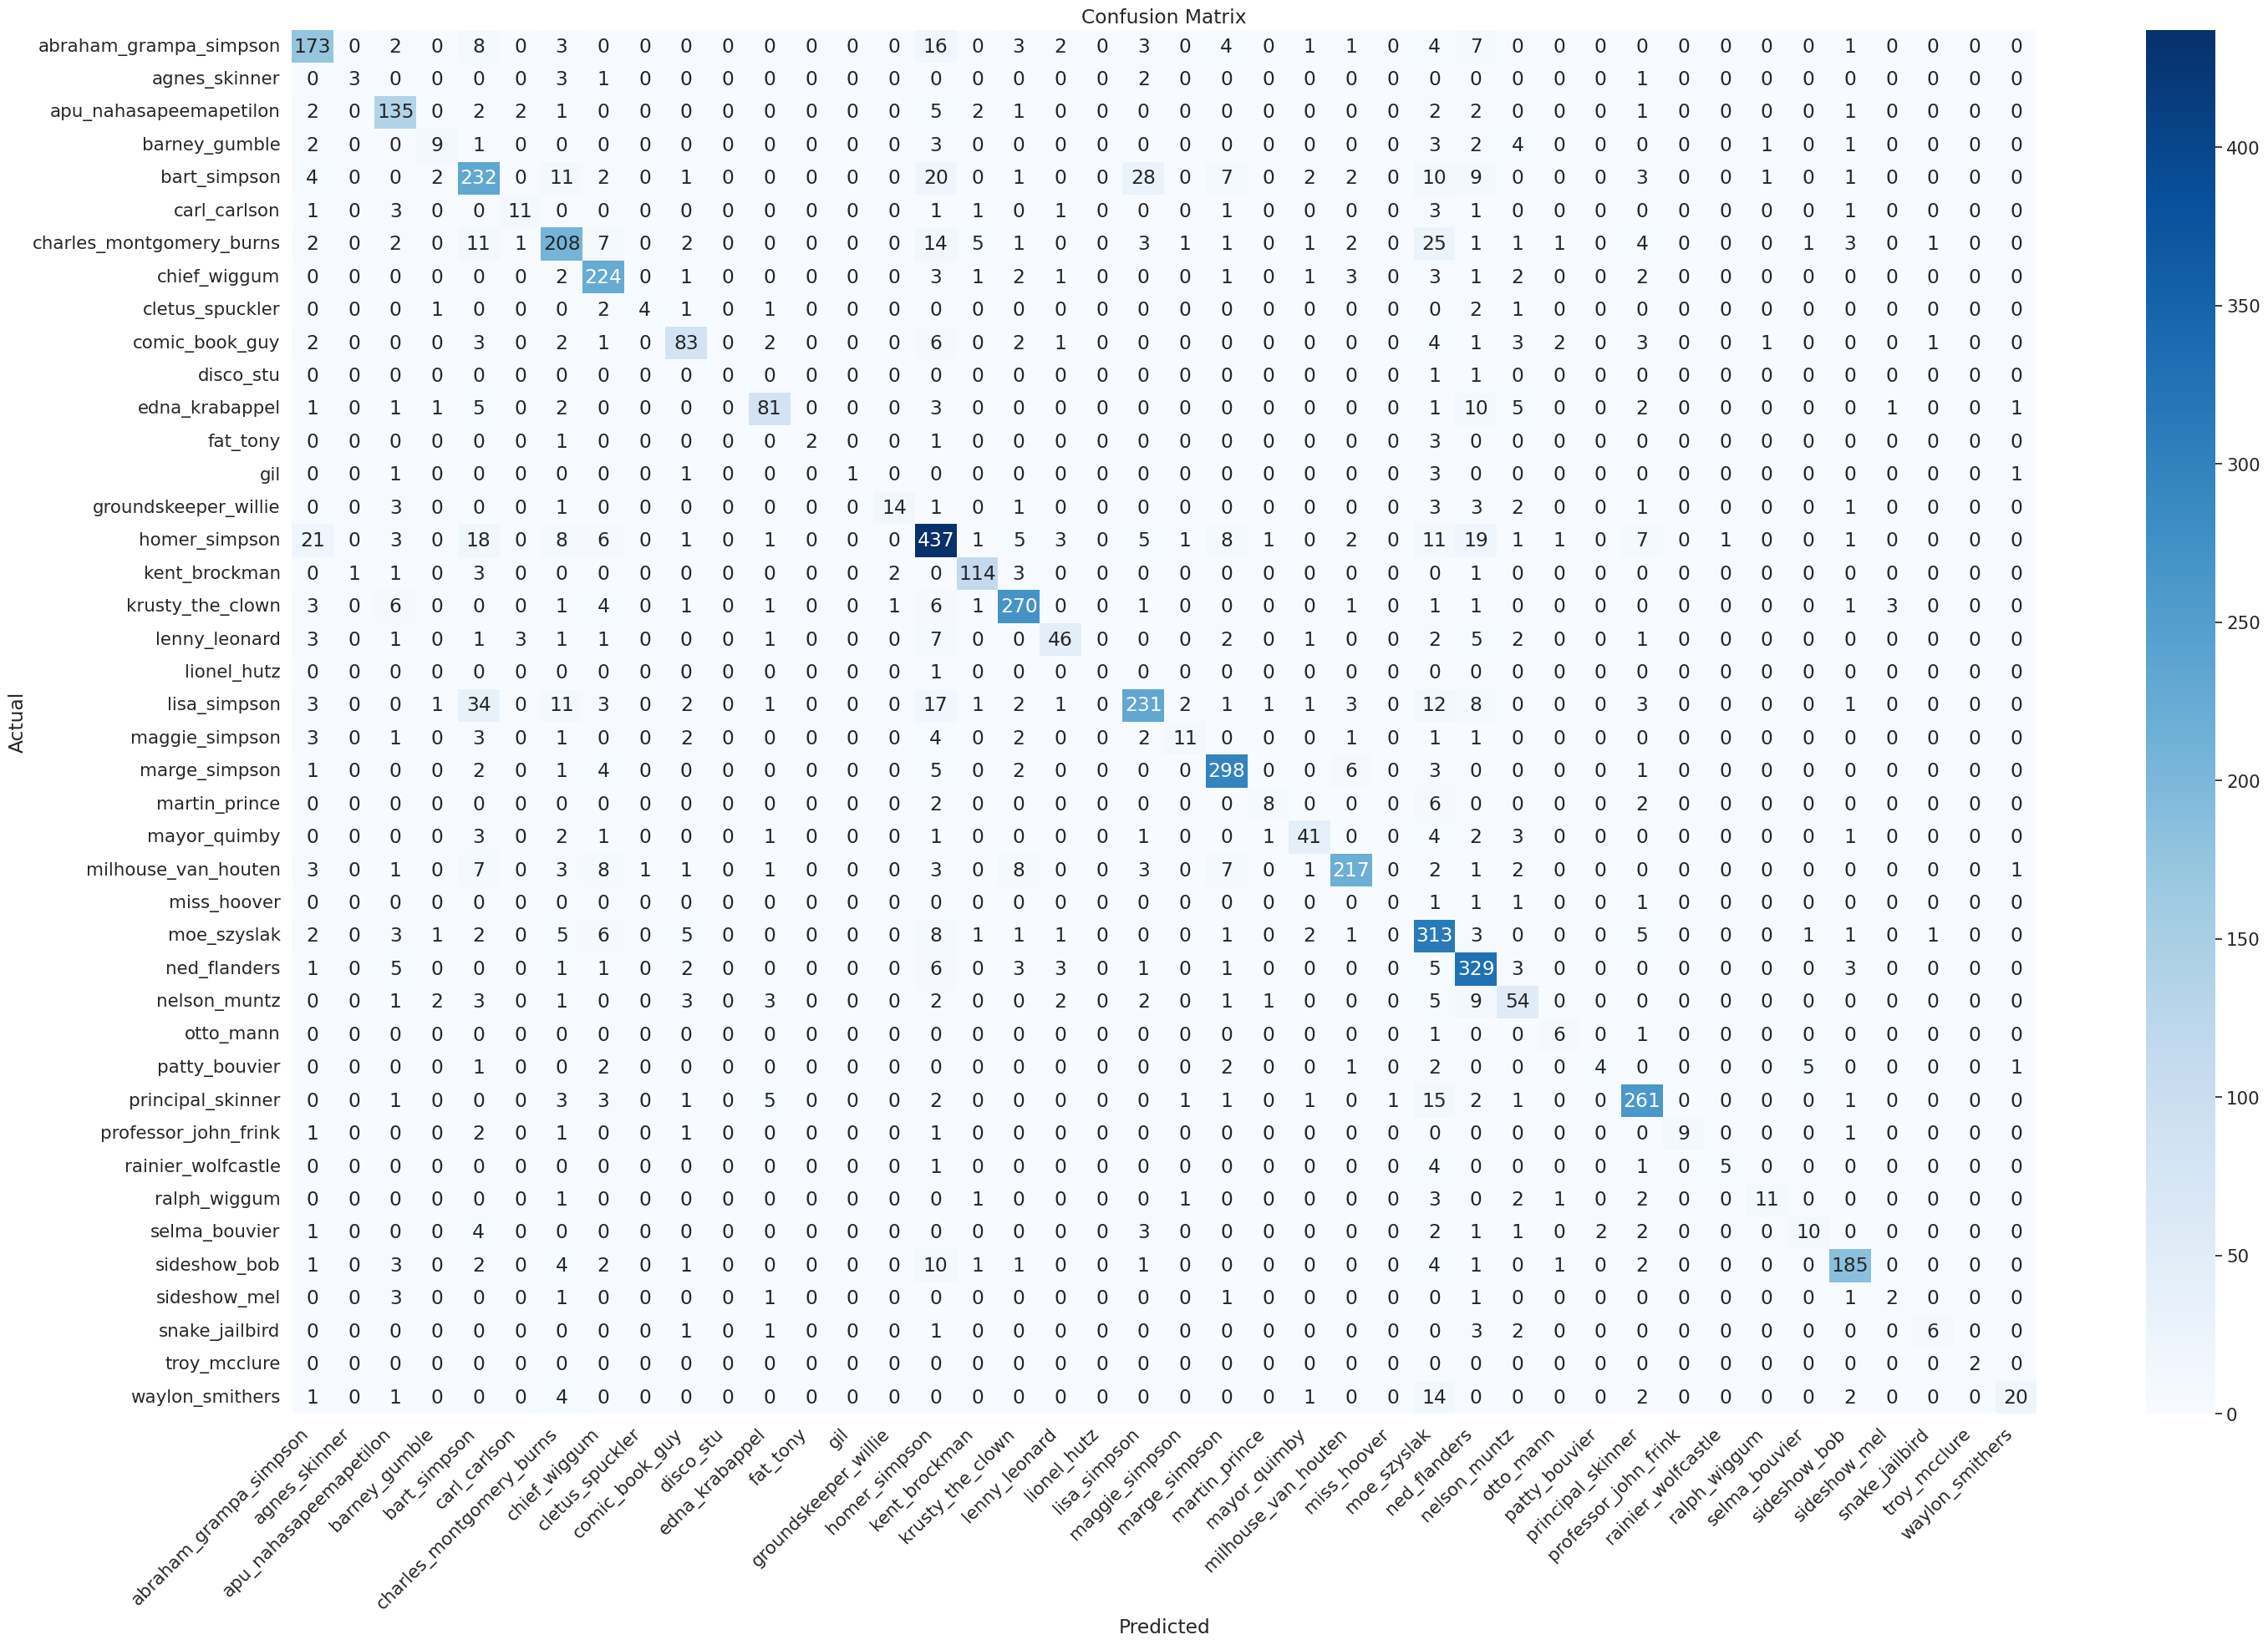

In [ ]:
cm = confusion_matrix(actual_labels_names, predicted_labels_names, labels=class_names)

plt.figure(figsize=(30, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Посмотим на изображения, в которых модель уверена, что предсказывает правильно, но на самом деле ошибкается в тренировочной выборке. Обратим внимание на следующие лейблы: miss_hoover, abraham_grandpa_simpson, bart_simpson, homer_simpson, moe_szyslak, ned_flanders, lisa_simpson.

In [ ]:
from collections import Counter

def find_suspicious_samples(model, dataloader, label_encoder, class_names_to_check, num_samples=20):
    """
    Находит подозрительные примеры, где модель очень уверена, но ошибается
    """
    model.eval()
    suspicious_samples = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            outp = model(X_batch)
            probs = torch.softmax(outp, dim=1)

            # Предсказания и уверенность
            preds = outp.argmax(-1)
            confidence = probs.max(dim=1)[0]

            # Переводим в numpy
            preds_np = preds.cpu().numpy()
            y_np = y_batch.cpu().numpy()
            conf_np = confidence.cpu().numpy()
            X_np = X_batch.cpu().numpy()

            # Ищем ошибки в интересующих классах
            for i in range(len(y_np)):
                true_class = label_encoder.inverse_transform([y_np[i]])[0]
                pred_class = label_encoder.inverse_transform([preds_np[i]])[0]

                # Если это интересующий нас класс и модель ошиблась
                if true_class in class_names_to_check and y_np[i] != preds_np[i]:
                    suspicious_samples.append({
                        'image': X_np[i],
                        'true_label': true_class,
                        'pred_label': pred_class,
                        'confidence': conf_np[i],
                        'true_idx': y_np[i],
                        'pred_idx': preds_np[i]
                    })

    # Сортируем по уверенности (самые уверенные ошибки - самые подозрительные)
    suspicious_samples.sort(key=lambda x: x['confidence'], reverse=True)

    return suspicious_samples[:num_samples]

In [ ]:
@torch.no_grad()
def show_suspicious_images(suspicious_samples, label_encoder, images_per_row=5):
    """
    Простая версия для быстрой визуализации
    """
    n_images = len(suspicious_samples)
    n_rows = (n_images + images_per_row - 1) // images_per_row

    fig, axs = plt.subplots(nrows=n_rows, ncols=images_per_row,
                            figsize=(images_per_row * 3, n_rows * 3))

    # Преобразуем axs в плоский список
    if n_rows == 1:
        axs = [axs]
    if images_per_row == 1:
        axs = [[ax] for ax in axs]
    axs_flat = axs.flatten() if hasattr(axs, 'flatten') else [axs]

    for idx in range(n_rows * images_per_row):
        if idx < n_images:
            sample = suspicious_samples[idx]

            # Получаем изображение
            if 'image' in sample:
                im_val = sample['image']
                if isinstance(im_val, np.ndarray):
                    im_val = torch.from_numpy(im_val)
            else:
                axs_flat[idx].axis('off')
                continue

            # Отображаем с помощью imshow
            imshow(im_val.data.cpu(), plt_ax=axs_flat[idx])

            # Метки
            true_label = sample['true_label']
            pred_label = sample['pred_label']
            confidence = sample.get('confidence', 0)

            if isinstance(true_label, (int, np.integer)):
                true_label = label_encoder.inverse_transform([true_label])[0]
            if isinstance(pred_label, (int, np.integer)):
                pred_label = label_encoder.inverse_transform([pred_label])[0]

            true_label = " ".join(map(lambda x: x.capitalize(), true_label.split('_')))
            pred_label = " ".join(map(lambda x: x.capitalize(), pred_label.split('_')))

            title = f"T:{true_label}\nP:{pred_label}\n{confidence:.1%}"
            axs_flat[idx].set_title(title, color='red', fontsize=8)

        else:
            axs_flat[idx].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def find_and_show_suspicious(model, dataloader, label_encoder, classes_to_check, num_samples=20, images_per_row=5):
    """
    Находит подозрительные примеры и показывает их с помощью show_suspicious_simple

    Args:
        model: обученная модель
        dataloader: даталоадер с данными для проверки
        label_encoder: label encoder для преобразования меток
        classes_to_check: список классов для проверки (например, ['cat', 'dog'])
        num_samples: количество подозрительных примеров для возврата
        images_per_row: количество изображений в ряду для визуализации
    """
    # Используем функцию поиска подозрительных примеров
    suspicious = find_suspicious_samples(
        model, dataloader, label_encoder,
        classes_to_check, num_samples
    )

    if len(suspicious) == 0:
        print(f"❌ Не найдено подозрительных примеров для классов {classes_to_check}")
        return []

    print(f"\n✅ Найдено {len(suspicious)} подозрительных примеров")
    print("=" * 60)
    print("САМЫЕ УВЕРЕННЫЕ ОШИБКИ:")
    print("=" * 60)

    for i, s in enumerate(suspicious[:10]):  # показываем топ-10 самых уверенных ошибок
        true_label = s['true_label']
        pred_label = s['pred_label']

        # Преобразуем индексы в названия если нужно
        if isinstance(true_label, (int, np.integer)):
            true_label = label_encoder.inverse_transform([true_label])[0]
        if isinstance(pred_label, (int, np.integer)):
            pred_label = label_encoder.inverse_transform([pred_label])[0]

        # Форматируем названия (убираем подчеркивания и капитализируем)
        true_label = " ".join(map(lambda x: x.capitalize(), true_label.split('_')))
        pred_label = " ".join(map(lambda x: x.capitalize(), pred_label.split('_')))

        print(f"{i+1:2d}. Истинный: {true_label:12} → Предсказанный: {pred_label:12} "
              f"(уверенность: {s['confidence']:.2f})")

    print("=" * 60)

    # Показываем изображения с помощью show_suspicious_simple
    show_suspicious_images(
        suspicious_samples=suspicious,
        label_encoder=label_encoder,
        images_per_row=images_per_row
    )

    return suspicious


✅ Найдено 20 подозрительных примеров
САМЫЕ УВЕРЕННЫЕ ОШИБКИ:
 1. Истинный: Lisa Simpson → Предсказанный: Homer Simpson (уверенность: 1.00)
 2. Истинный: Lisa Simpson → Предсказанный: Moe Szyslak  (уверенность: 1.00)
 3. Истинный: Homer Simpson → Предсказанный: Ned Flanders (уверенность: 0.99)
 4. Истинный: Moe Szyslak  → Предсказанный: Chief Wiggum (уверенность: 0.99)
 5. Истинный: Lisa Simpson → Предсказанный: Bart Simpson (уверенность: 0.99)
 6. Истинный: Homer Simpson → Предсказанный: Lenny Leonard (уверенность: 0.99)
 7. Истинный: Bart Simpson → Предсказанный: Moe Szyslak  (уверенность: 0.97)
 8. Истинный: Lisa Simpson → Предсказанный: Principal Skinner (уверенность: 0.96)
 9. Истинный: Lisa Simpson → Предсказанный: Ned Flanders (уверенность: 0.96)
10. Истинный: Homer Simpson → Предсказанный: Moe Szyslak  (уверенность: 0.96)


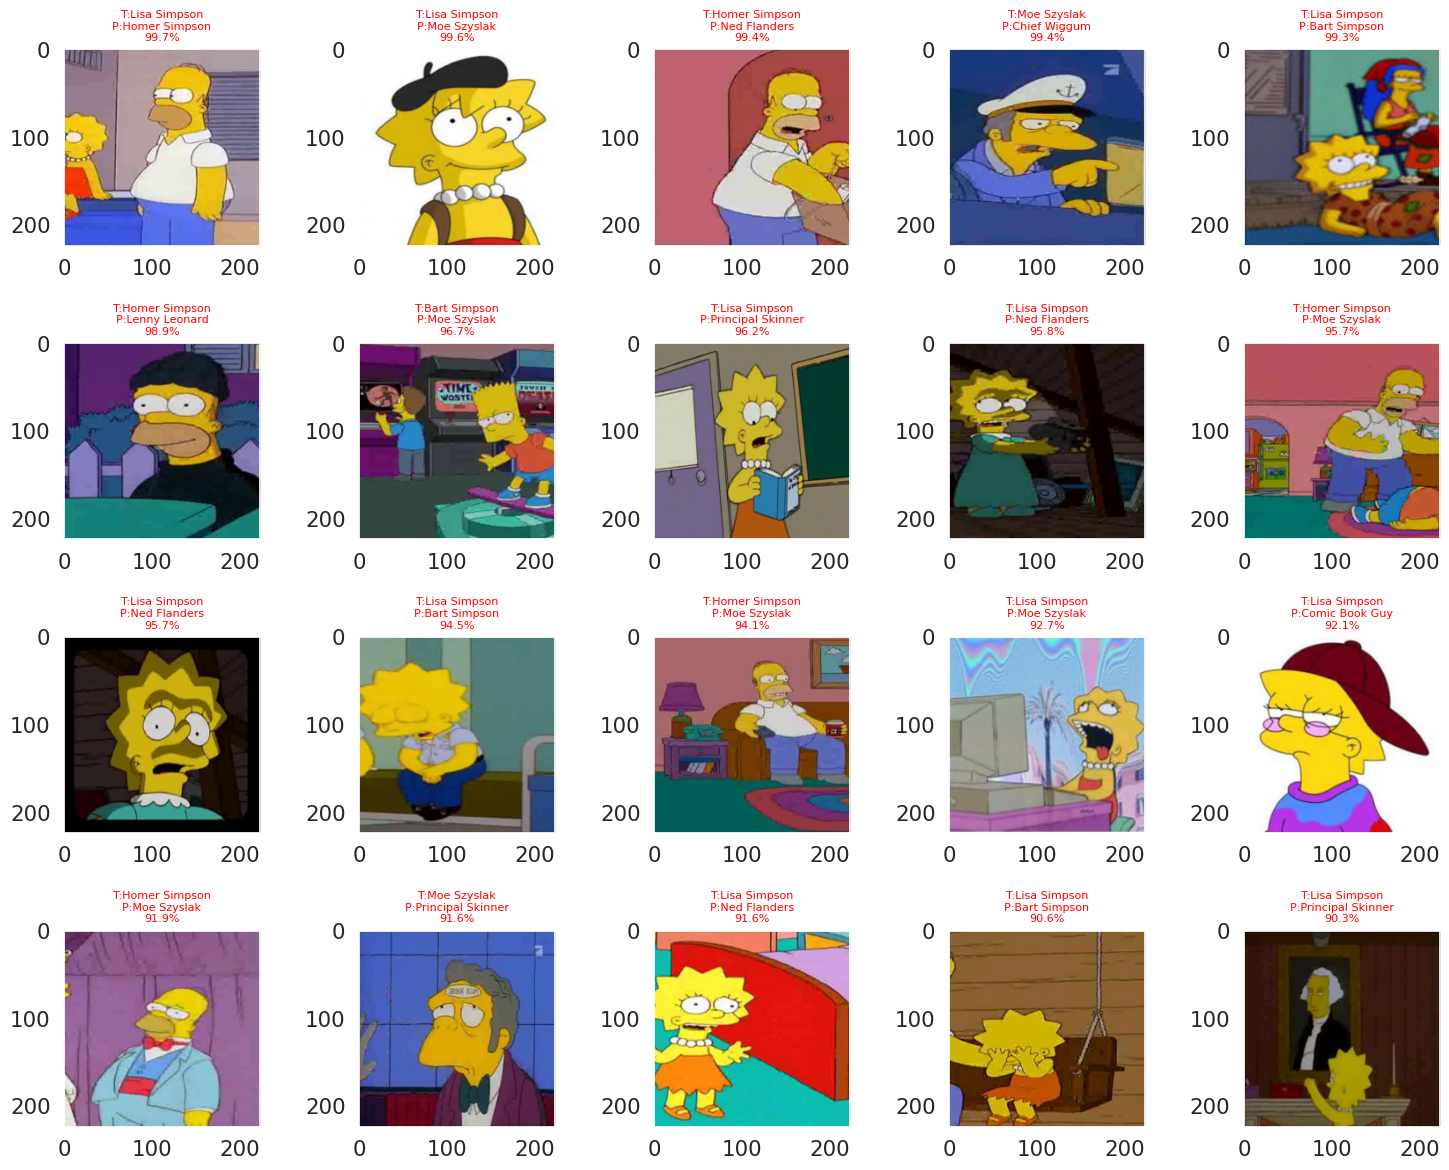

In [ ]:
suspicious = find_and_show_suspicious(
    model=model_simple_cnn,
    dataloader=loaders['train'],
    label_encoder=label_encoder,
    classes_to_check=['miss_hoover', 'abraham_grandpa_simpson', 'bart_simpson', 'homer_simpson', 'moe_szyslak', 'ned_flanders', 'lisa_simpson'],
    num_samples=20,
    images_per_row=5
)

Видно, что есть одна картинка, где Lisa изображена вместе с Homer, что ввело нейросеть в заблуждение. Это изображение pic_0632.jpg (случайно нашёл вручную). Но в основном - это просто неправильная классификация. Поэтому удалим эту одну картинку и далее будем только дорабатывать структуру нейросети, а также добавим аугментации изображений.

In [21]:
import os

file_path = TRAIN_DIR / "simpsons_dataset" / "lisa_simpson" / "pic_0632.jpg"

if file_path.exists():
    file_path.unlink()
    print(f"✅ Файл {file_path} успешно удален")
else:
    print(f"❌ Файл {file_path} не найден")

✅ Файл content\train\simpsons_dataset\lisa_simpson\pic_0632.jpg успешно удален


Добавим аугментации изображений. Изменим класс SimpsonsDataset.

In [37]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_ # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.
        # Если вы решите перевзвесить размеры категорий внутри класса -
        # не забудьте изменить вывод self.__len__()

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(degrees=15),
            v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
            v2.Resize(RESCALE_SIZE),
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),

          ])
      else:
        transform = v2.Compose([
            v2.Resize(RESCALE_SIZE),
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),

          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)

Снова разделим выборку, так как удалили из неё один файл.

In [38]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [39]:
label_encoder = LabelEncoder()

train_val_labels = [path.parent.name for path in train_val_files]

label_encoder.fit(train_val_labels)

LabelEncoder()

In [40]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

Преобразуем датасет:

In [41]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

In [42]:
batch_size = 64

In [43]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

Изменяем модель нейросети:

In [44]:
class SimpleCnn_2(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5), # изменили kernel на 5 на первом слое
            nn.BatchNorm2d(8), # добавили batchnorm
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.BatchNorm2d(16), # добавили batchnorm
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32), # добавили batchnorm
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64), # добавили batchnorm
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.BatchNorm2d(96), # добавили batchnorm
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )


        self.fc1 = nn.Sequential( # добавили слой
            nn.Linear(96 * 5 * 5, 256),
            nn.BatchNorm1d(256), # добавили batchnorm
            nn.ReLU()
        )
        self.fc2 = nn.Sequential( # добавили слой
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), # добавили batchnorm
            nn.ReLU()
        )
        self.out = nn.Linear(128, n_classes) # изменили out


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        logits = self.out(x)
        return logits

In [ ]:
model_simple_cnn_2 = SimpleCnn_2(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn_2.to(DEVICE)
torchsummary.summary(model_simple_cnn_2, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 220, 220]             608
       BatchNorm2d-2          [-1, 8, 220, 220]              16
              ReLU-3          [-1, 8, 220, 220]               0
         MaxPool2d-4          [-1, 8, 110, 110]               0
            Conv2d-5         [-1, 16, 108, 108]           1,168
       BatchNorm2d-6         [-1, 16, 108, 108]              32
              ReLU-7         [-1, 16, 108, 108]               0
         MaxPool2d-8           [-1, 16, 54, 54]               0
            Conv2d-9           [-1, 32, 52, 52]           4,640
      BatchNorm2d-10           [-1, 32, 52, 52]              64
             ReLU-11           [-1, 32, 52, 52]               0
        MaxPool2d-12           [-1, 32, 26, 26]               0
           Conv2d-13           [-1, 64, 24, 24]          18,496
      BatchNorm2d-14           [-1, 64,

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn_2.parameters(), lr = 1e-3)

Обучаем:

In [ ]:
f1_scores = train_func(model = model_simple_cnn_2, num_epochs = 10, dataloaders = loaders, optimizer = optimizer, loss_func = criterion)


Epoch: 1


100%|██████████| 246/246 [03:37<00:00,  1.13it/s]


f1_score_train: 0.4918



100%|██████████| 82/82 [00:28<00:00,  2.84it/s]


f1_score_val: 0.6377


Epoch: 2


...

f1_score_val: 0.8634


Epoch: 10


100%|██████████| 246/246 [03:11<00:00,  1.28it/s]


f1_score_train: 0.9238



100%|██████████| 82/82 [00:24<00:00,  3.33it/s]

f1_score_val: 0.8702


results:
best f1 for val set: 0.8702
best epoch for val set: 10


Визуализация

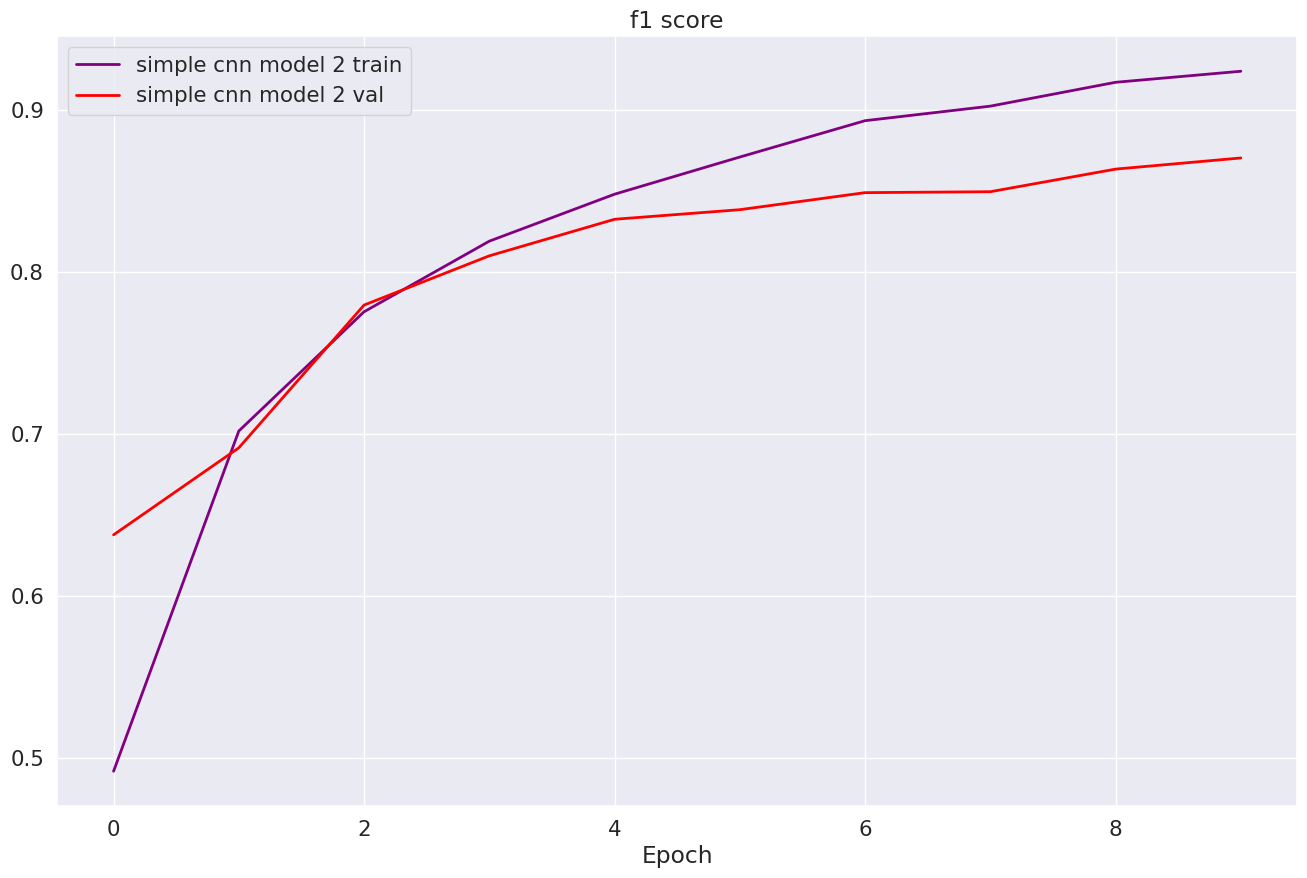

In [ ]:
import seaborn as sns

sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("f1 score")
plt.plot(range(10), f1_scores["train"], label="simple cnn model 2 train", linewidth=2, color = 'purple')
plt.plot(range(10), f1_scores["valid"], label="simple cnn model 2 val", linewidth=2, color = 'red')
plt.legend()
plt.xlabel("Epoch")
plt.show()

# YOUR CODE

Как видно модель гораздо меньше переобучается и продолжает улучшаться на валидации даже на 10-й эпохе.

Создаём сабмит:

In [ ]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [ ]:
predicted_numeric_labels = predict(model_simple_cnn_2, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

In [ ]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [ ]:
my_submission.to_csv('simple_cnn_baseline_2.csv', index=False)

Результат: Score: 0.93092. Как ни странно, результат ухудшился (примерно на 0.01).

##**Часть 3. Transfer learning.**

Судя по источникам в интернете, наиболее подходящая модель для данной задачи - это EfficientNetB2. Будем использовать её и попробуем дообучить.

In [10]:
from torchvision import models

model = models.efficientnet_b2(pretrained=True)

c:\Users\Admin\Desktop\DLS\dlsenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\Desktop\DLS\dlsenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B2_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
# замораживаем параметры (веса)
for param in model.parameters():
    param.requires_grad = False

In [12]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

На вход в классификатор подается вектор фич размером 1408.

In [13]:
num_features = 1408

# Количество классов в нашем датасете
num_classes = 42

# Изменяем классификатор под нашу задачу. Оставляем dropout без изменений, по сути изменяем только num_classes
model.classifier = nn.Sequential(
    torch.nn.Dropout(p=0.3, inplace=True),
    torch.nn.Linear(num_features, num_classes)
)

Передаём в оптимизатор только параметры классификатора. В PyTorch параметры новых слоев (которые мы создали в model.classifier) по умолчанию имеют requires_grad = True, даже если до этого мы заморозили всю модель. Поэтому явно размораживать классификатор не нужно — достаточно передать его параметры в оптимизатор.

In [14]:
optimizer = torch.optim.Adam(model.classifier.parameters(), lr = 1e-3)
criterion = nn.CrossEntropyLoss()

Переносим модель на gpu для вычислений.

In [15]:
model.to(DEVICE)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Для EfficientNet-B2 входной размер должен быть 260x260. Поэтому нужно предобработать изображения.

In [16]:
RESCALE_SIZE = [260, 260]

Менять параметры нормализации (NORMALIZE_MEAN, NORMALIZE_STD) не нужно, так как у нас и так выставлены стандартные значения для ImageNet, которые идеально подходят для EfficientNet-B2.

Немного поменям класс SimpsonsDataset. Сделаем сначала resize, а уже затем аугментации в тренировочном датасете.

In [17]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_ # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.
        # Если вы решите перевзвесить размеры категорий внутри класса -
        # не забудьте изменить вывод self.__len__()

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.Resize(RESCALE_SIZE),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(degrees=15),
            v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),

          ])
      else:
        transform = v2.Compose([
            v2.Resize(RESCALE_SIZE),
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),

          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)

Обрабатываем датасет:

In [18]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [19]:
label_encoder = LabelEncoder()

train_val_labels = [path.parent.name for path in train_val_files]

label_encoder.fit(train_val_labels)

LabelEncoder()

In [20]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

In [21]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

In [22]:
batch_size = 32 # Уменьшили, чтобы освободить память GPU

In [23]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

Обучаем классификатор модели:

In [24]:
f1_scores = train_func(model = model, num_epochs = 10, dataloaders = loaders, optimizer = optimizer, loss_func = criterion)


Epoch: 1


100%|██████████| 491/491 [01:27<00:00,  5.59it/s]


f1_score_train: 0.5339



100%|██████████| 164/164 [00:20<00:00,  8.08it/s]


f1_score_val: 0.6742


Epoch: 2


...

f1_score_val: 0.7625


Epoch: 10


100%|██████████| 491/491 [01:28<00:00,  5.57it/s]


f1_score_train: 0.7558



100%|██████████| 164/164 [00:19<00:00,  8.44it/s]

f1_score_val: 0.7682


results:
best f1 for val set: 0.7682
best epoch for val set: 10


Визуализация:

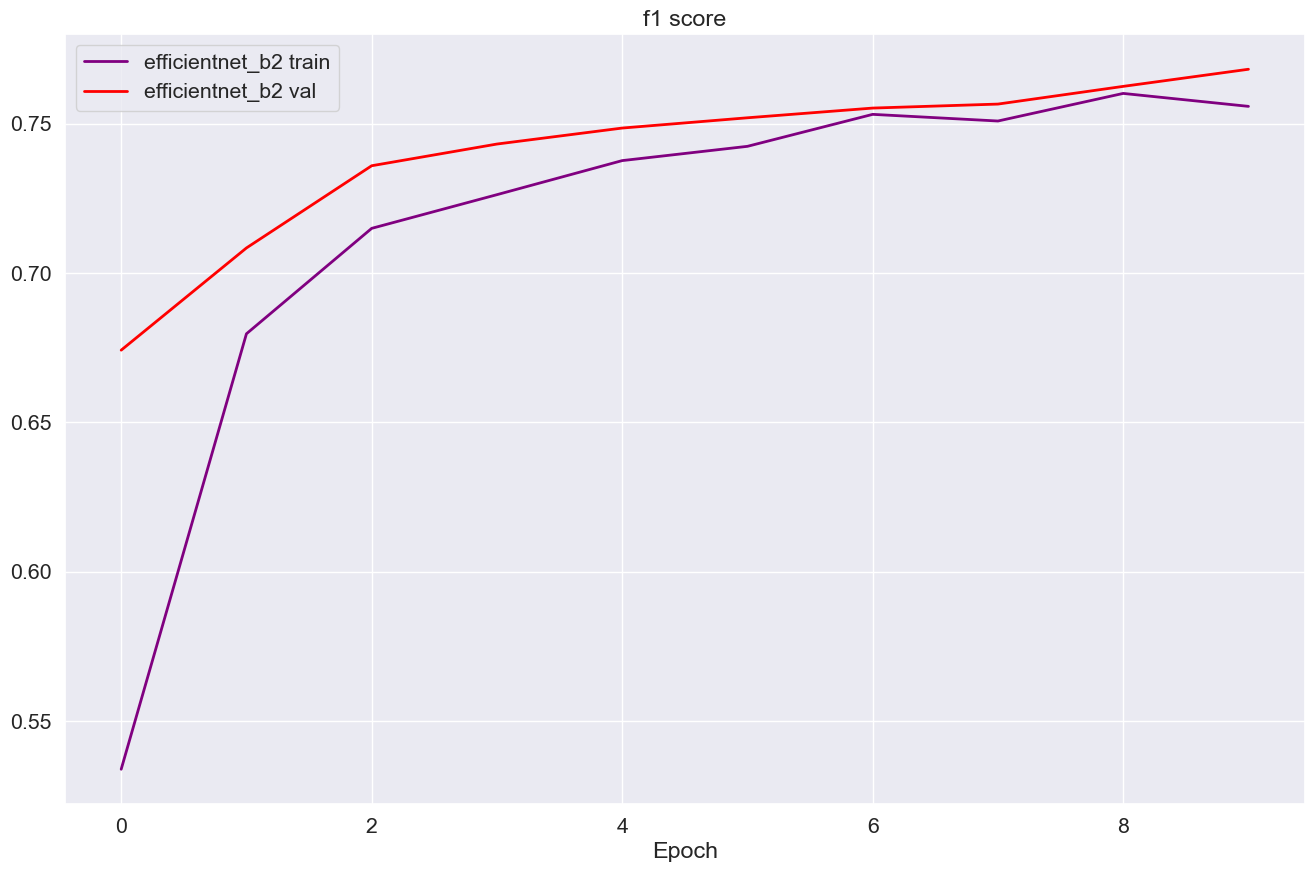

In [25]:
import seaborn as sns

sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("f1 score")
plt.plot(range(10), f1_scores["train"], label="efficientnet_b2 train", linewidth=2, color = 'purple')
plt.plot(range(10), f1_scores["valid"], label="efficientnet_b2 val", linewidth=2, color = 'red')
plt.legend()
plt.xlabel("Epoch")
plt.show()

# YOUR CODE

Создаём сабмит:

In [61]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [62]:
predicted_numeric_labels = predict(model, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

In [63]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

In [64]:
import pandas as pd

my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [65]:
my_submission.to_csv('simple_cnn_baseline_3.csv', index=False)

Результат на kaggle: 0.74070

Очищаем кэш и старый оптимайзер, чтобы освободить память GPU:

In [26]:
del optimizer

torch.cuda.empty_cache() 

Теперь попробуем разморозить все парамектры модели и дообучить ещё на 30 эпох с меньшим lr.

In [27]:
# Размораживаем веса модели
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {'params': model.features.parameters(), 'lr': 1e-5},  # База — медленно
    {'params': model.classifier.parameters(), 'lr': 1e-4} # Голова — быстрее
])

In [28]:
f1_scores = train_func(model = model, num_epochs = 30, dataloaders = loaders, optimizer = optimizer, loss_func = criterion)


Epoch: 1


100%|██████████| 491/491 [02:39<00:00,  3.08it/s]


f1_score_train: 0.8444



100%|██████████| 164/164 [00:19<00:00,  8.47it/s]


f1_score_val: 0.8878


Epoch: 2


...

f1_score_val: 0.9708


Epoch: 30


100%|██████████| 491/491 [02:11<00:00,  3.73it/s]


f1_score_train: 0.9980



100%|██████████| 164/164 [00:19<00:00,  8.62it/s]

f1_score_val: 0.9719


results:
best f1 for val set: 0.9723
best epoch for val set: 28


Визуализация:

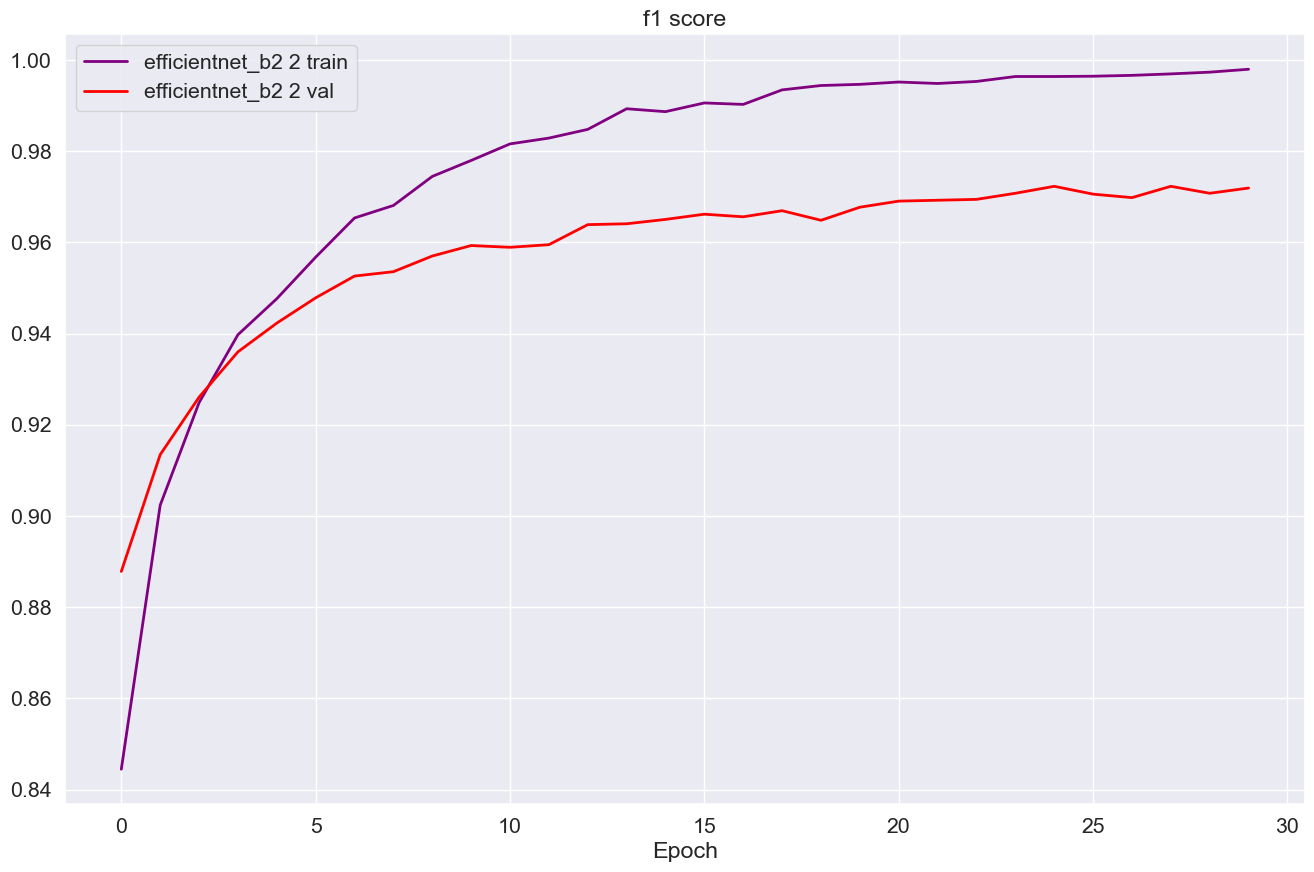

In [30]:
import seaborn as sns

sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("f1 score")
plt.plot(range(30), f1_scores["train"], label="efficientnet_b2 2 train", linewidth=2, color = 'purple')
plt.plot(range(30), f1_scores["valid"], label="efficientnet_b2 2 val", linewidth=2, color = 'red')
plt.legend()
plt.xlabel("Epoch")
plt.show()

# YOUR CODE

Создаём сабмит:

In [31]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [32]:
predicted_numeric_labels = predict(model, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

In [33]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

In [34]:
import pandas as pd

my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [35]:
my_submission.to_csv('simple_cnn_baseline_4.csv', index=False)

Результат на kaggle: 0.99256!

**Мой ник на kaggle leaderboard: Артём_Мордвинов_1057351207** 